# Task 1: Problem Identification

## Selected Problem Type: Image Classification

The dataset represents an image classification problem because each image belongs to exactly one class:
- normal
- scratch
- dent
- stain

The goal is to classify each product image into one of these four categories.

In [69]:
import os
import zipfile
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

os.makedirs('results', exist_ok=True)
os.makedirs('sample_predictions', exist_ok=True)

In [70]:
if os.path.exists('images.zip') and not os.path.exists('images'):
    with zipfile.ZipFile('images.zip', 'r') as zip_ref:
        zip_ref.extractall('.')
    print('images.zip extracted successfully.')
else:
    print('Images folder already exists or ZIP file not found.')

Images folder already exists or ZIP file not found.


# Task 2: Dataset Exploration

In [71]:
# Dataset Paths
DATASET_DIR = 'images'
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

In [72]:
classes = sorted([
    folder for folder in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, folder))
])

# Number of classes
print('Classes:', classes)
print('Number of Classes:', len(classes))

# Number of images per class
class_counts = {}
for cls in classes:
    class_dir = os.path.join(DATASET_DIR, cls)
    class_counts[cls] = len(os.listdir(class_dir))

class_counts_df = pd.DataFrame(
    list(class_counts.items()),
    columns=['Class', 'Image Count']
)
class_counts_df

Classes: ['dent', 'normal', 'scratch', 'stain']
Number of Classes: 4


,Class,Image Count
0,dent,120
1,normal,120
2,scratch,120
3,stain,120


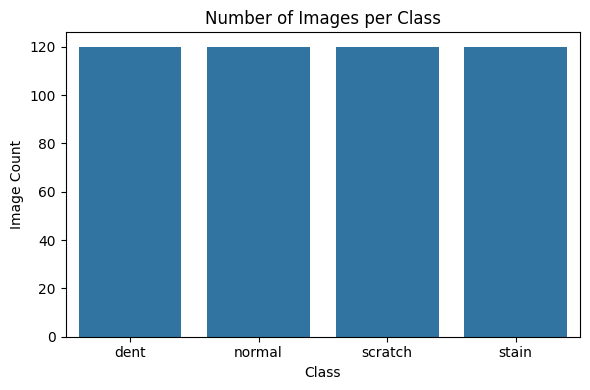

In [73]:
# Number of images per class (class distribution plot)
plt.figure(figsize=(6, 4))
sns.barplot(data=class_counts_df, x='Class', y='Image Count')
plt.title('Number of Images per Class')
plt.tight_layout()
plt.show()

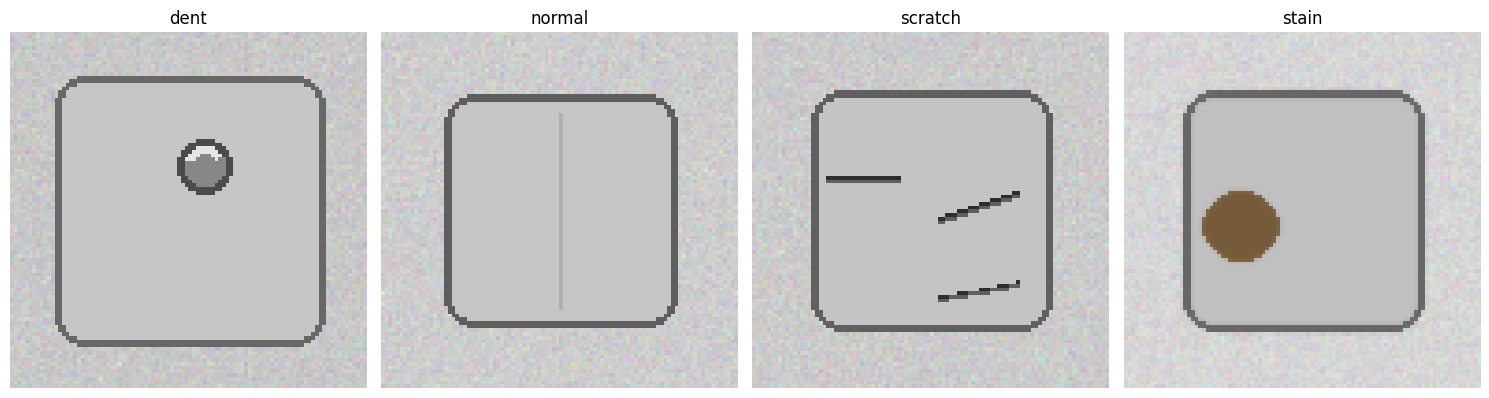

In [74]:
# Sample images from each class
fig, axes = plt.subplots(1, len(classes), figsize=(15, 4))

for i, cls in enumerate(classes):
    class_dir = os.path.join(DATASET_DIR, cls)
    sample_image = os.listdir(class_dir)[0]
    img_path = os.path.join(class_dir, sample_image)

    img = plt.imread(img_path)

    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [75]:
# Image dimensions
for cls in classes:
    class_dir = os.path.join(DATASET_DIR, cls)
    sample_image = os.listdir(class_dir)[0]
    img_path = os.path.join(class_dir, sample_image)
    img = plt.imread(img_path)
    print(f'{cls}: {img.shape}')

dent: (96, 96, 3)
normal: (96, 96, 3)
scratch: (96, 96, 3)
stain: (96, 96, 3)


# Task 3: Image Preprocessing

In [76]:
# Image Preprocessing and Data Generators

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# Training generator
train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

# Validation generator
val_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.


Images were resized to 128 × 128 pixels, normalized to the range [0, 1], and split into training and validation sets. Data augmentation was applied to improve generalization.

# Task 4: CNN Model Creation

In [77]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(classes), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

# Task 5: Model Training and Evaluation

In [78]:
# Train Model
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.2917 - loss: 1.4891 - val_accuracy: 0.2500 - val_loss: 1.3817
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.2474 - loss: 1.3869 - val_accuracy: 0.4167 - val_loss: 1.3707
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.3776 - loss: 1.3409 - val_accuracy: 0.5625 - val_loss: 1.3028
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.5026 - loss: 1.1823 - val_accuracy: 0.4896 - val_loss: 1.1539
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.5729 - loss: 1.0150 - val_accuracy: 0.5938 - val_loss: 0.8796
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.6693 - loss: 0.7882 - val_accuracy: 0.7708 - val_loss: 0.6966
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.7109 - loss: 0.6531 - val_accuracy: 0.8021 - val_loss: 0.4988
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.7786 - loss: 0.5099 - val_accuracy: 0.9271 - val_loss:

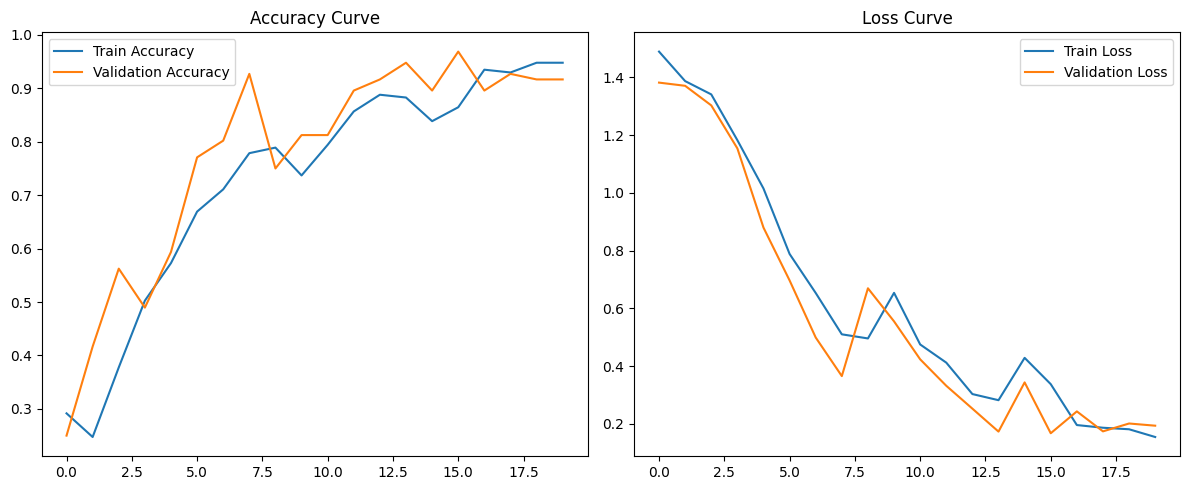

In [79]:
# Plot Accuracy and Loss Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Accuracy Curve')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Loss Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/accuracy_loss_curves.png')
plt.show()

In [80]:
# Evaluate Model
val_loss, val_accuracy = model.evaluate(val_generator, verbose=0)
print(f'Validation Loss: {val_loss:.4f}')
print(f'Validation Accuracy: {val_accuracy:.4f}')

Validation Loss: 0.1979
Validation Accuracy: 0.9271


              precision    recall  f1-score   support

        dent       0.96      1.00      0.98        24
      normal       0.95      0.83      0.89        24
     scratch       0.85      0.92      0.88        24
       stain       1.00      1.00      1.00        24

    accuracy                           0.94        96
   macro avg       0.94      0.94      0.94        96
weighted avg       0.94      0.94      0.94        96



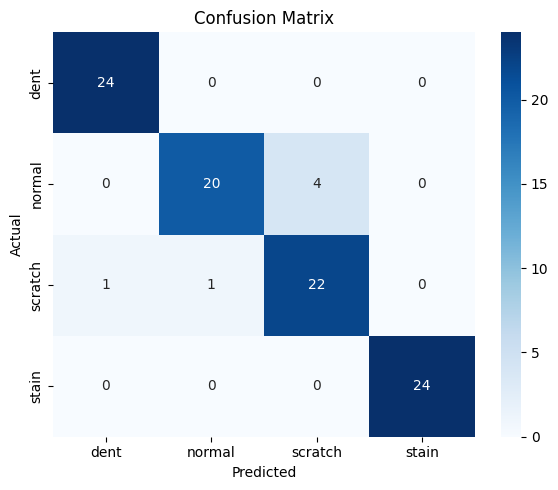

In [81]:
# Predictions and Confusion Matrix
pred_probs = model.predict(val_generator, verbose=0)
y_pred = np.argmax(pred_probs, axis=1)
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_labels))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png')
plt.show()

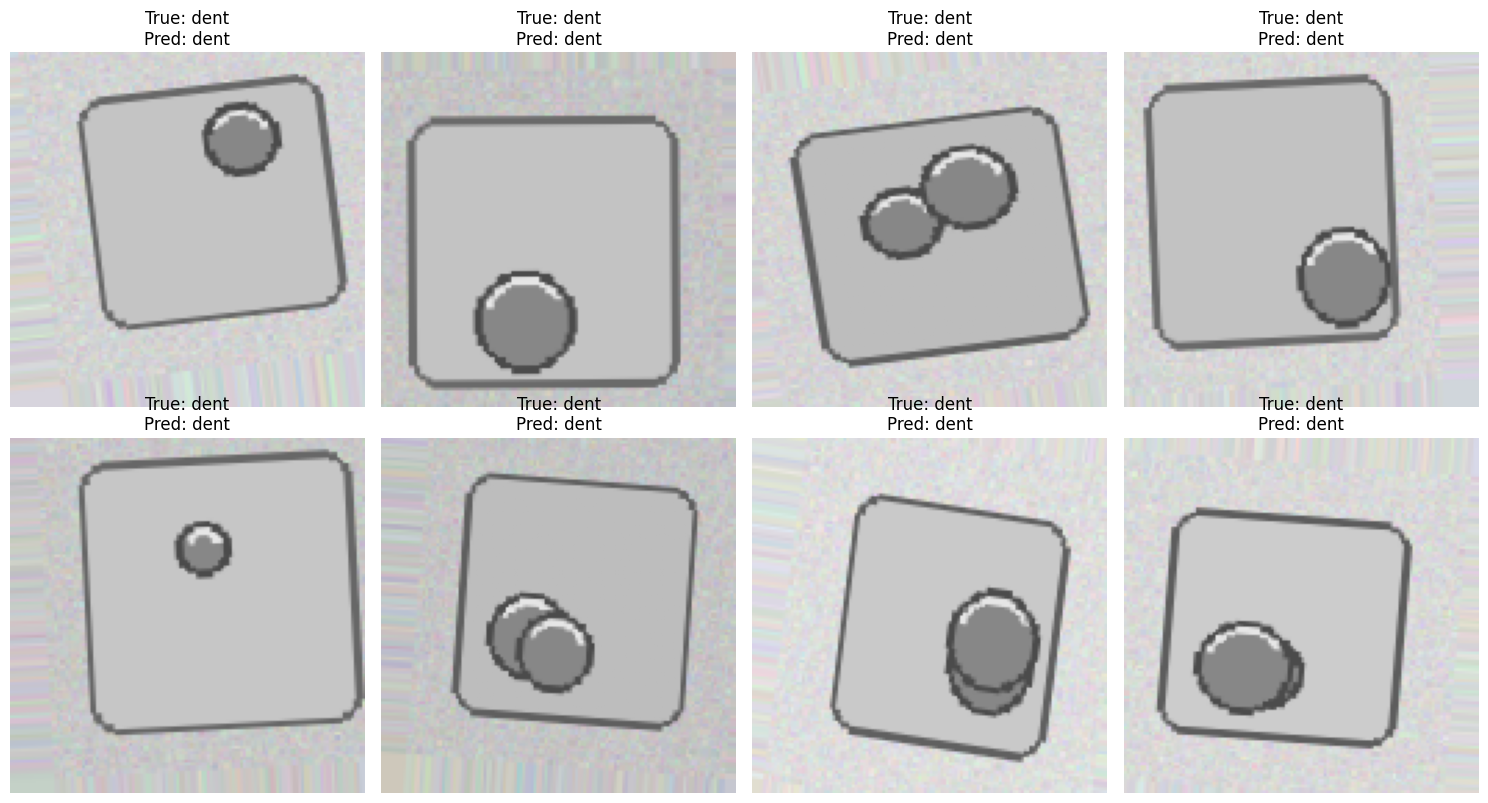

In [82]:
# Sample Predictions
images, labels = next(val_generator)
predictions = model.predict(images, verbose=0)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(labels, axis=1)

plt.figure(figsize=(15, 8))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])
    plt.title(
        f'True: {class_labels[true_classes[i]]}\n'
        f'Pred: {class_labels[predicted_classes[i]]}'
    )
    plt.axis('off')

plt.tight_layout()
plt.savefig('sample_predictions/prediction_outputs.png')
plt.show()

# Task 6: CNN Concept Explanation

## What is convolution?
Convolution is the process of applying a small filter ( kernel) to an image to detect important patterns such as edges, corners, textures, and shapes.

The filter slides across the image and performs element-wise multiplication with the pixel values. The result is a feature map that highlights specific visual patterns.

For example:
- Early layers may detect edges and lines.
- Middle layers may detect textures or defect shapes.
- Deeper layers may detect complex objects such as scratches or dents.

## Why is pooling used?
Pooling is used to reduce the size of feature maps while preserving the most important information.

The most common type is **Max Pooling**, which selects the maximum value from a small region (for example, 2×2).

Benefits of pooling:
- Reduces computational cost
- Reduces the number of parameters
- Helps prevent overfitting
- Makes the model more robust to small shifts in the image

## Why is ReLU commonly used?
ReLU (Rectified Linear Unit) is an activation function defined as:

f(x) = max(0, x)

It replaces negative values with zero and keeps positive values unchanged.

Advantages of ReLU:
- Introduces non-linearity
- Computationally efficient
- Helps reduce the vanishing gradient problem
- Speeds up model training

## Why are CNNs better than feed-forward networks for images?
CNNs preserve spatial relationships and require far fewer parameters by sharing weights.

CNNs are specifically designed to process images.

#### 1. Preserve Spatial Relationships
CNNs analyze local regions of an image, allowing them to capture spatial patterns such as edges and shapes.

#### 2. Weight Sharing
The same filter is applied across the entire image, greatly reducing the number of parameters.

#### 3. Translation Invariance
CNNs can recognize features even if they appear in different positions.

#### 4. Automatic Feature Extraction
CNNs learn useful features directly from raw pixel values, eliminating the need for manual feature engineering.

In contrast, regular feed-forward networks flatten the image into a long vector, which loses spatial structure and requires a much larger number of parameters.

# Task 7: Business Use Case Mapping

## Manufacturing Quality Inspection

This CNN can be used in manufacturing to automatically detect product defects such as scratches, dents, and stains.

Traditionally, quality inspection is performed manually by human inspectors, which can be time-consuming, expensive, and prone to inconsistency. A CNN-based image classification model can analyze images captured by cameras on the production line and classify each product as either normal or defective.

If a defect is detected, the system can automatically remove the product from the production line or alert operators for further inspection.

Benefits include:
- Ensures consistent quality standards
- Improves inspection speed and efficiency
- Reduced human error
- Lower labor costs
- Improved product quality
- Real-time defect detection on production lines

### Real-World Impact

Manufacturers in industries such as automotive, electronics, and consumer goods can use this technology to maintain high product quality while increasing productivity and reducing operational costs.